In [96]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [97]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [98]:
'''record info for all the valid paths
    a list of a single path (start -> boundary end) (dynamic length), 
    a single boundary result, 
'''
def pathGenerator(v, segments, g, eps = 0.001, maxSteps = 16, maxR = 10):
    x0 = v
    path = []
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return path, g(x0)
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
    return [], 0


In [99]:
target = []
width = range(1, 20)
height = range(1, 20)
for i in width:
    for j in height:
        target.append(np.array([i/10 - 1, j/10 - 1]))

print(len(target))

361


In [100]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]

#v = np.array([0, 0])
def boundary(v):
    return v[1] * v[0]

In [101]:
paths = []
boundaries = []
for v in target:
    p, b = pathGenerator(v, segments, boundary)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)

In [102]:
len(paths)

297

In [103]:
class ZNN(keras.Model):
    def __init__(self, units):
        super(ZNN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(2)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x)
        return x

In [104]:
class YNN(keras.Model):
    def __init__(self, units):
        super(YNN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(1)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x)
        return x

In [105]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layerZ, layerY):
        super(Ysolver, self).__init__()
        self.Ymodel = YNN(layerY)
        self.Zmodel = ZNN(layerZ)
        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training):
        y_pred = self.Ymodel(np.array(path[0]).reshape(1,2).astype("float32"), training)
        for i in range(len(path) - 1): ###input path should be (-1, 2) shaped nparray, no len()
            z = self.Zmodel(np.array(path[i]).reshape(1,2).astype("float32"), training) #obtain gradients for steps
            y_pred += tf.reduce_sum(z * (path[i + 1] - path[i]), 1, keepdims=True) #accumulating
            #print(y_pred)
        #y_pred += self.y
        return y_pred

In [106]:
class NNsolver(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver([32, 12, 12], [12, 12, 12])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.square(delta)
        return loss

    def train_step(self, x, training):
        return self.model(x, training)

    def train(self): 
        training_history = []
        for i in range(len(self.paths)):
            with tf.GradientTape() as tape:
                y_pred = self.train_step(np.array(self.paths[i]).reshape(-1, 2), training = True)
                loss = self.loss_fn(y_pred,self.boundary[i])

            training_vars = self.model.trainable_variables
            #print(str(i) + " " + str(loss))
            grad = tape.gradient(loss, training_vars)
            self.optimizer.apply_gradients(zip(grad, training_vars))
            
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch):
        for i in range(epoch):
            cur_history = self.train()
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [107]:
training = NNsolver(paths, boundaries)
training.train_epoch(30)

epoch: 0 loss: 0.20086096
epoch: 1 loss: 0.17260545
epoch: 2 loss: 0.15390384
epoch: 3 loss: 0.13782638
epoch: 4 loss: 0.123806655
epoch: 5 loss: 0.111542195
epoch: 6 loss: 0.10084909
epoch: 7 loss: 0.091311015
epoch: 8 loss: 0.08248314
epoch: 9 loss: 0.07416048
epoch: 10 loss: 0.066835895
epoch: 11 loss: 0.060638852
epoch: 12 loss: 0.055220548
epoch: 13 loss: 0.050598487
epoch: 14 loss: 0.046656016
epoch: 15 loss: 0.043367073
epoch: 16 loss: 0.040589463
epoch: 17 loss: 0.038233876
epoch: 18 loss: 0.036215715
epoch: 19 loss: 0.034423456
epoch: 20 loss: 0.032799743
epoch: 21 loss: 0.0313608
epoch: 22 loss: 0.030045666
epoch: 23 loss: 0.02887024
epoch: 24 loss: 0.027800675
epoch: 25 loss: 0.026835635
epoch: 26 loss: 0.025992163
epoch: 27 loss: 0.025216589
epoch: 28 loss: 0.024548678
epoch: 29 loss: 0.023945805


In [108]:
training.model.Ymodel(np.array([-1, -1]).reshape([1, 2]).astype("float32"))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.6306275]], dtype=float32)>

In [109]:
training.train_step(np.array(paths[21]).reshape(-1, 2), training = True)

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.54967517]], dtype=float32)>

In [110]:
print(paths[21])
print(boundaries[21])

ListWrapper([array([-0.8, -0.4]), array([-0.96759715, -0.50913842]), array([-0.93657896, -0.49976738]), array([-0.97259151, -0.55197203]), array([-0.99188438, -0.57144021]), array([-0.9846924 , -0.57520034]), array([-0.99960003, -0.57867672])])
0.5784452682892746


In [111]:

width = range(201)
height = range(201)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/100 - 1)
        Y.append(j/100 - 1)
        Z.append(training.model.Ymodel(np.array([i/100 - 1 ,j/100 - 1]).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(201, 201)
Y = np.array(Y).reshape(201, 201)
Z = np.array(Z).reshape(201, 201)


(201, 201)


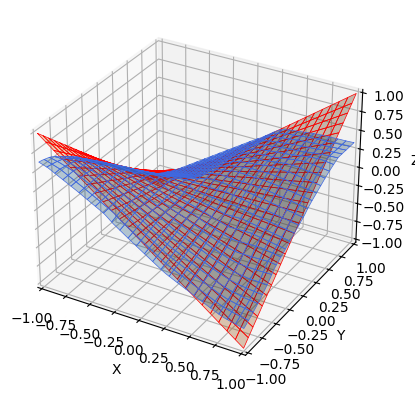

In [112]:
Z1 = X * Y
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()